# Exploratory Data Analysis (EDA)
The goal here is to check the distribution of our variables, find any anomalies, and discover patterns that influence final decision.

In [250]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
file_path = "cleaned.csv"
df = pd.read_csv(file_path, encoding='latin-1')

## 1. Basic Descriptive Statistics
Before visualizations, let's look at the raw numbers. Here, we generate a statistical summary for attributes to get a basic understanding of their distributions.

In [251]:
key_columns = ['age', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
stats_summary = df[key_columns].describe().T

stats_summary['median'] = df[key_columns].median()
stats_summary['skewness'] = df[key_columns].skew()

display(stats_summary)

,count,mean,std,min,25%,50%,75%,max,median,skewness
age,8267.0,26.359623,3.570178,18.0,24.0,26.0,28.0,55.0,26.0,1.068007
attr,8105.0,6.191783,1.949538,0.0,5.0,6.0,8.0,10.0,6.0,-0.321283
sinc,8030.0,7.175031,1.741436,0.0,6.0,7.0,8.0,10.0,7.0,-0.638093
intel,8011.0,7.367807,1.549073,0.0,6.0,7.0,8.0,10.0,7.0,-0.534793
fun,7957.0,6.400842,1.950856,0.0,5.0,7.0,8.0,10.0,7.0,-0.450705
amb,7596.0,6.778699,1.794109,0.0,6.0,7.0,8.0,10.0,7.0,-0.396953
shar,7240.0,5.475207,2.152986,0.0,4.0,6.0,7.0,10.0,6.0,-0.194768


## 2. Demographics and Participant Profile
We need to analyze the basic demographics: age distribution and gender balance.

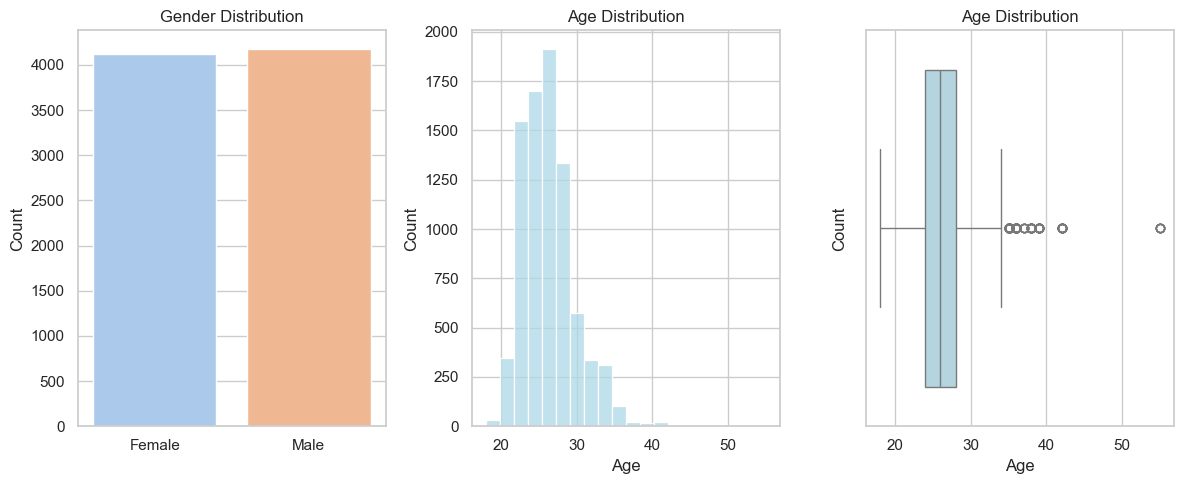

In [252]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

gender_data = df['gender'].map({0: 'Female', 1: 'Male'})
sns.countplot(x=gender_data, hue=gender_data, ax=ax1, palette='pastel')
ax1.set_title('Gender Distribution')
ax1.set_xlabel('')
ax1.set_ylabel('Count')

sns.histplot(df['age'], bins=20, color='lightblue', ax=ax2)
ax2.set_title('Age Distribution')
ax2.set_xlabel('Age')
ax2.set_ylabel('Count')

sns.boxplot(x=df['age'], color='lightblue')
ax3.set_title('Age Distribution')
ax3.set_xlabel('Age')
ax3.set_ylabel('Count')


plt.tight_layout()
plt.show()

## 3. Stated Preferences
Before the speed dating rounds, participants were asked to distribute a total of 100 points among six key attributes to indicate their importance.

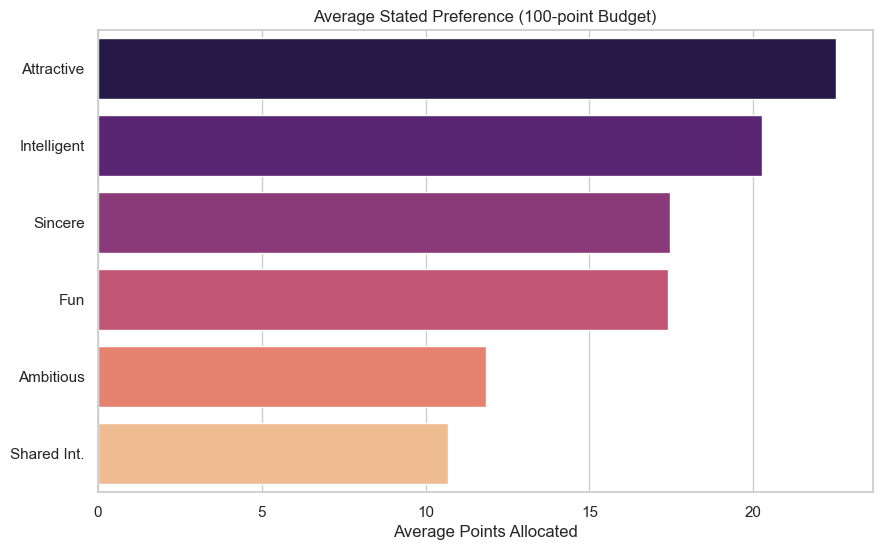

In [253]:
stated_cols = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
centurion_means = df[stated_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=centurion_means.values, y=['Attractive', 'Intelligent', 'Sincere', 'Fun', 'Ambitious', 'Shared Int.'], 
            palette='magma', hue=centurion_means.index, legend=False)
plt.title('Average Stated Preference (100-point Budget)')
plt.xlabel('Average Points Allocated')
plt.show()

## 4. Importance of Demographic Similarity
These histograms illustrate how much weight participants place on finding a partner of the same racial or religious background.

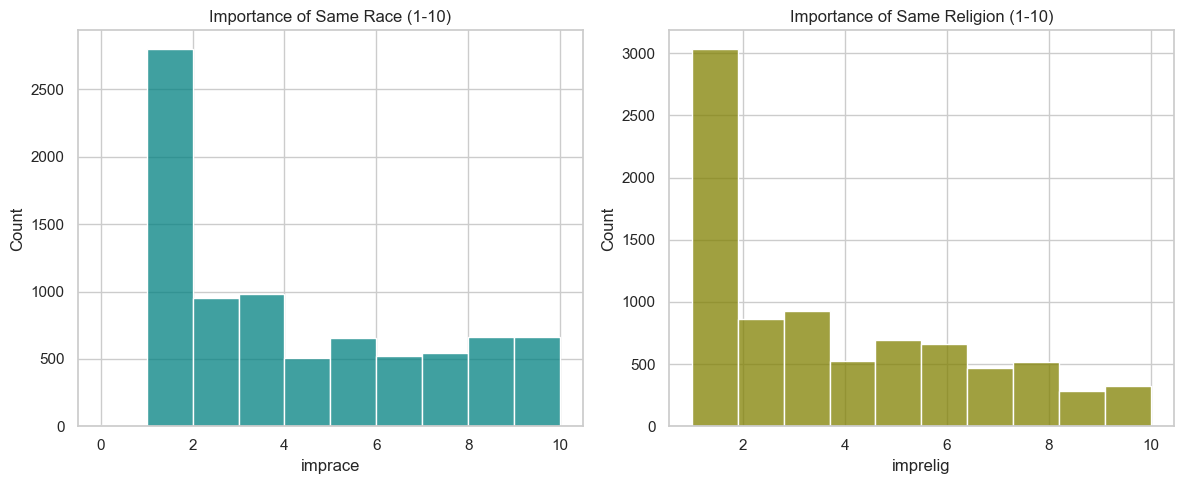

In [254]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['imprace'].dropna(), bins=10, color='teal')
plt.title('Importance of Same Race (1-10)')

plt.subplot(1, 2, 2)
sns.histplot(df['imprelig'].dropna(), bins=10, color='olive')
plt.title('Importance of Same Religion (1-10)')

plt.tight_layout()
plt.show()

## 5. Distribution of Partner Ratings
During the speed dates, participants rated their partners on a scale from 1 to 10 across 6 key attribute. These histograms help us see if people were critics or if they used the full grading scale.

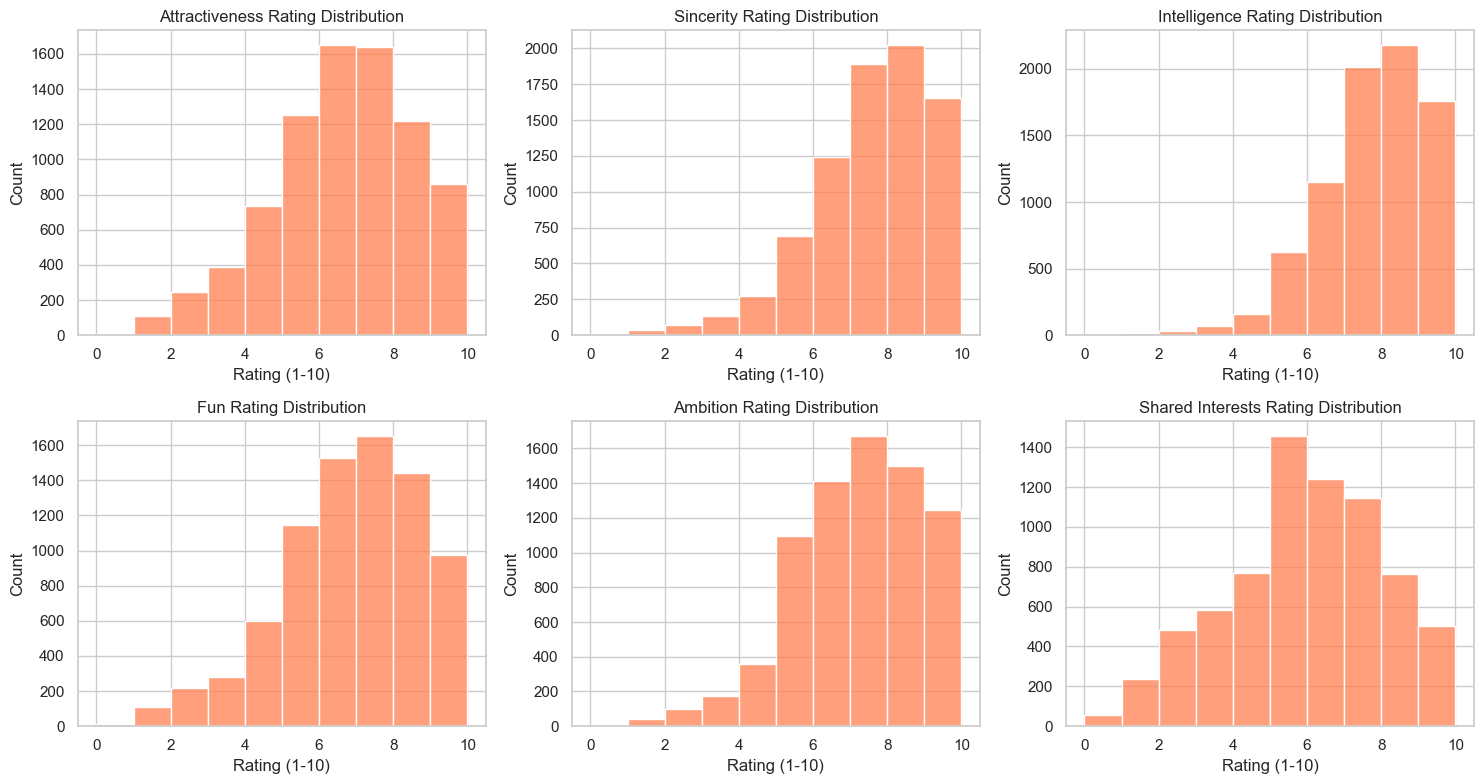

In [255]:
attributes = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
titles = ['Attractiveness', 'Sincerity', 'Intelligence', 'Fun', 'Ambition', 'Shared Interests']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(attributes):
    sns.histplot(data=df, x=col, bins=10, ax=axes[i], color='coral')
    axes[i].set_title(f'{titles[i]} Rating Distribution')
    axes[i].set_xlabel('Rating (1-10)')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 6. Participant Goals and Target Variable Imbalance
We check why people decided to join the event and we analyze the distribution of our target variable `match`.

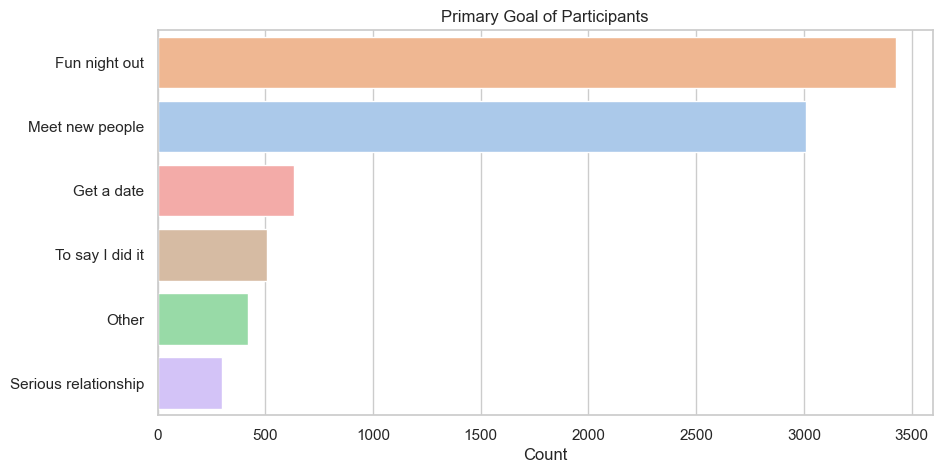

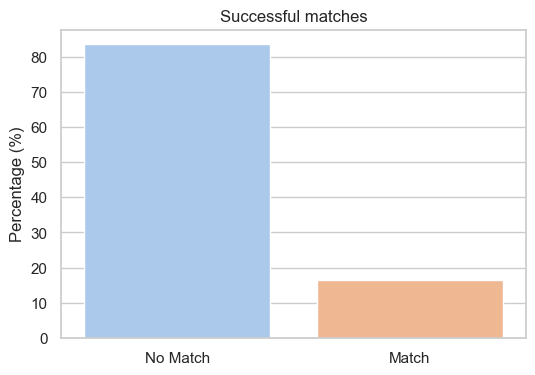

Percentage of successful matches: 16.45%


In [256]:
goal_map = {1: 'Fun night out', 2: 'Meet new people', 3: 'Get a date', 
            4: 'Serious relationship', 5: 'To say I did it', 6: 'Other'}
goal_labels = df['goal'].map(goal_map)
order_labels = goal_labels.value_counts().index

plt.figure(figsize=(10, 5))
sns.countplot(y=goal_labels, order=order_labels, hue=goal_labels, palette='pastel', legend=False)
plt.title('Primary Goal of Participants')
plt.xlabel('Count')
plt.ylabel('')
plt.show()

# Calculating match ratio to expose potential target class imbalance
match_counts = df['match'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
x_labels = match_counts.index.map({0: 'No Match', 1: 'Match'})
sns.barplot(x=x_labels, y=match_counts.values, hue=x_labels, palette='pastel', legend=False)
plt.title('Successful matches')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.show()

print(f"Percentage of successful matches: {match_counts[1]:.2f}%")

## 7. The Impact of Hobbies on Popularity
The dataset includes 17 columns about participants' hobbies. After finding the most popular activities, we check their correlation with the amount of "Yes" votes a person received from their partners (`dec_o`). The goal is to see if having a specific interest statistically translates to being more attractive on a date.

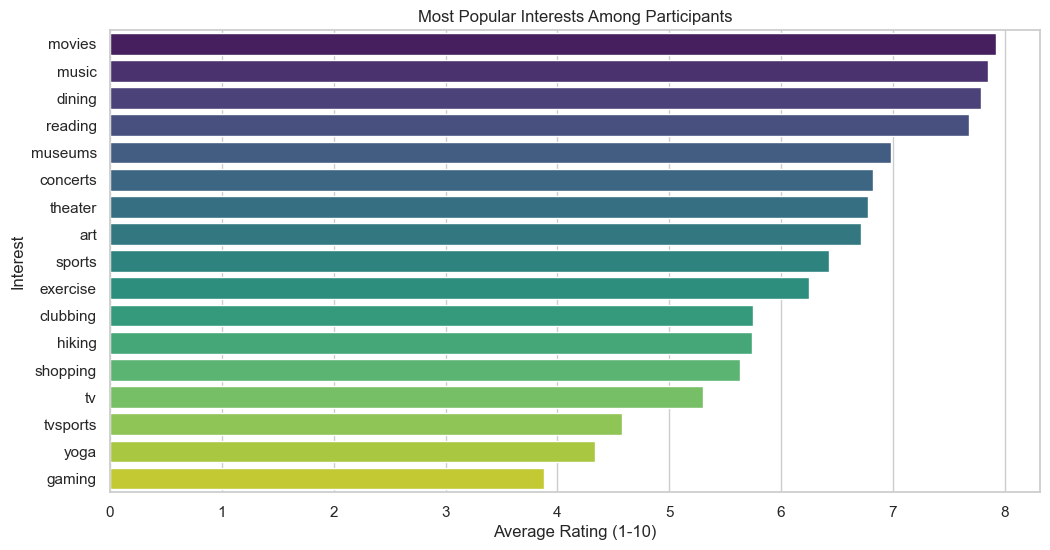

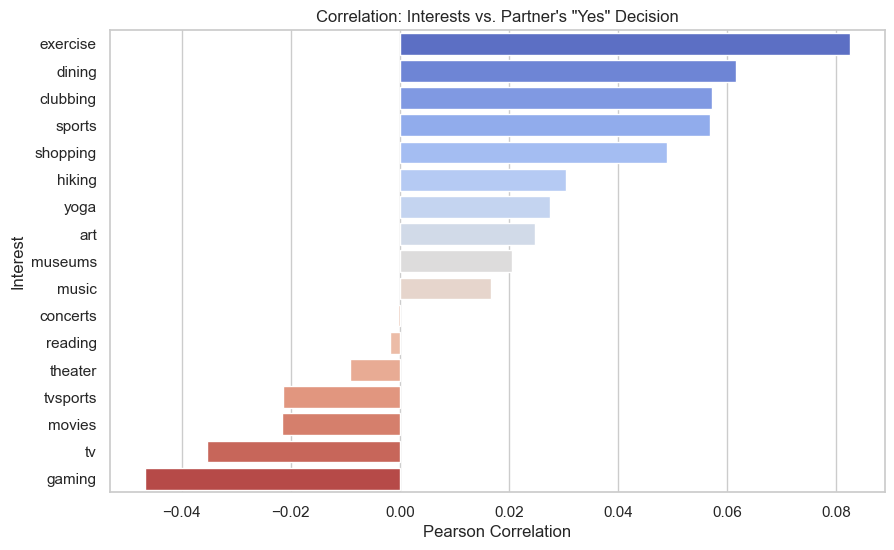

In [257]:
interests = ['sports', 'tvsports', 'exercise', 'dining', 'museums', 
             'art', 'hiking', 'gaming', 'clubbing', 'reading', 
             'tv', 'theater', 'movies', 'concerts', 'music', 
             'shopping', 'yoga']

# Calculate the average score for each hobby and sort them
popular_hobbies = df[interests].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=popular_hobbies.values, y=popular_hobbies.index, palette='viridis', hue=popular_hobbies.index, legend=False)
plt.title('Most Popular Interests Among Participants')
plt.xlabel('Average Rating (1-10)')
plt.ylabel('Interest')
plt.show()

# Does having a specific interest get you more "Yes" votes?
# We use 'dec_o' (decision of the partner) to measure participant popularity
interest_popularity_corr = df[interests + ['dec_o']].corr()['dec_o'].drop('dec_o').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=interest_popularity_corr.values, 
    y=interest_popularity_corr.index, 
    palette='coolwarm', 
    hue=interest_popularity_corr.index, 
    legend=False
)

plt.title('Correlation: Interests vs. Partner\'s "Yes" Decision')
plt.xlabel('Pearson Correlation')
plt.ylabel('Interest')
plt.show()

## 8. Professional Backgrounds and Dating Success
This analysis examines the distribution of intended career paths among participants and how these professional choices impact their dating success. By correlating career categories with partners' positive decisions, we can identify if specific professions carry a statistical advantage in a speed dating environment.

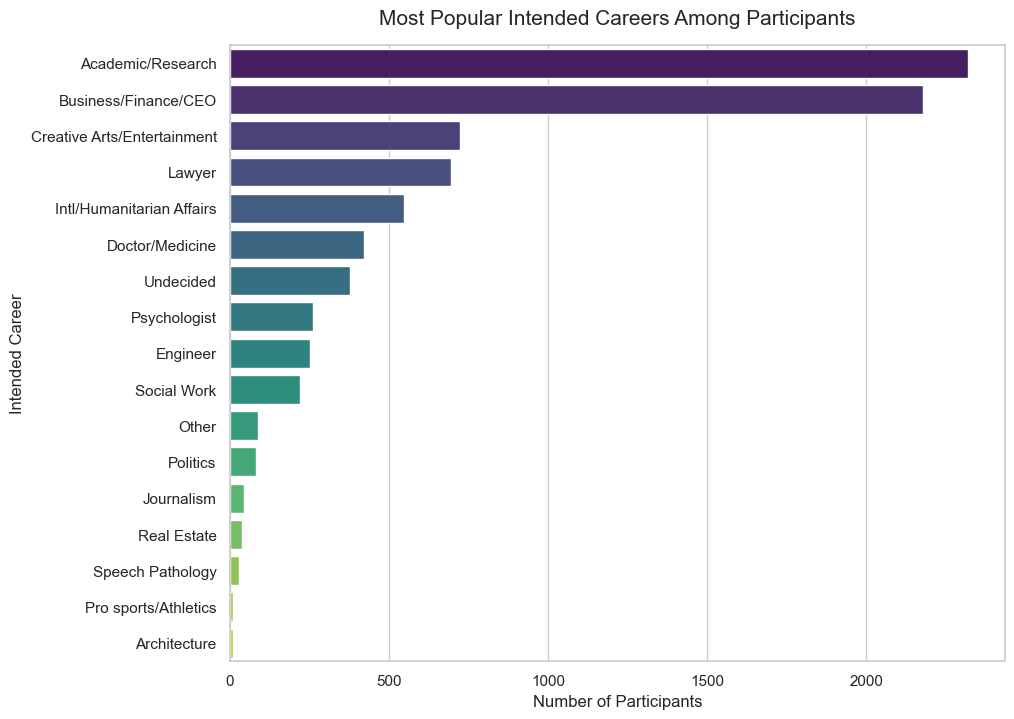

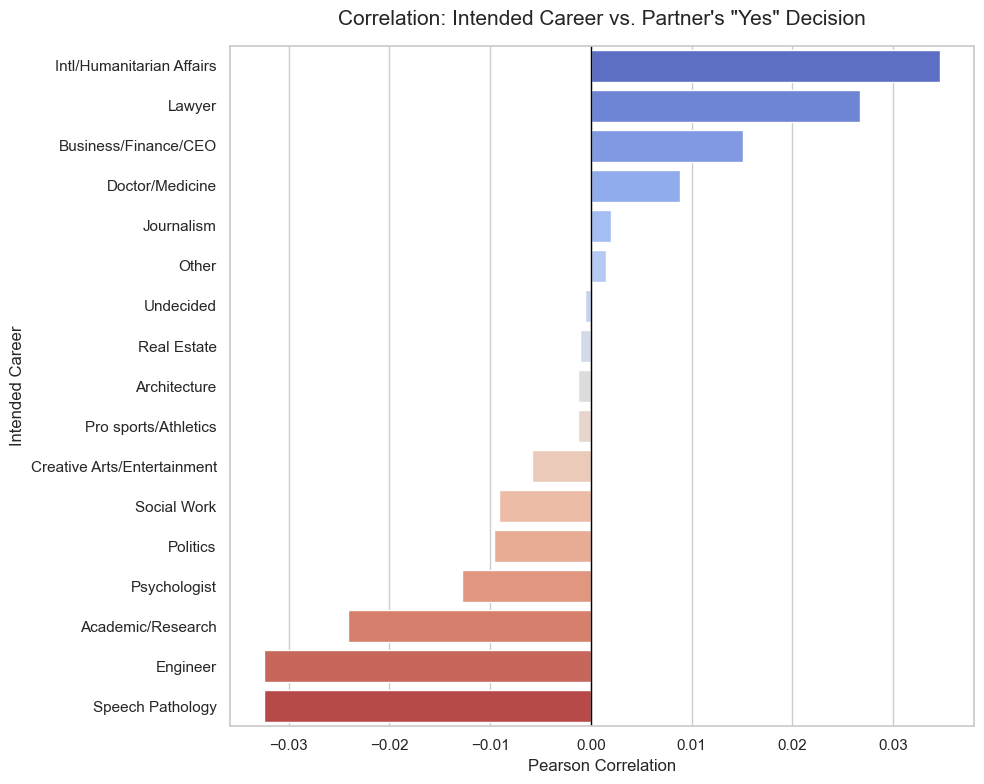

In [258]:
career_mapping = {
    1: 'Lawyer',
    2: 'Academic/Research',
    3: 'Psychologist',
    4: 'Doctor/Medicine',
    5: 'Engineer',
    6: 'Creative Arts/Entertainment',
    7: 'Business/Finance/CEO', 
    8: 'Real Estate',
    9: 'Intl/Humanitarian Affairs',
    10: 'Undecided',
    11: 'Social Work',
    12: 'Speech Pathology',
    13: 'Politics',
    14: 'Pro sports/Athletics',
    15: 'Other',
    16: 'Journalism',
    17: 'Architecture'
}

df['career_name'] = df['career_c'].map(career_mapping)

popular_careers = df['career_name'].value_counts()

plt.figure(figsize=(10, 8))
sns.barplot(
    x=popular_careers.values, 
    y=popular_careers.index, 
    palette='viridis', 
    hue=popular_careers.index, 
    legend=False
)

plt.title('Most Popular Intended Careers Among Participants', fontsize=15, pad=15)
plt.xlabel('Number of Participants', fontsize=12)
plt.ylabel('Intended Career', fontsize=12)
plt.show()

career_dummies = pd.get_dummies(df['career_name'], dtype=float)
data_for_corr = pd.concat([career_dummies, df['dec_o']], axis=1).dropna()

career_corr = data_for_corr.corr()['dec_o'].drop('dec_o').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=career_corr.values, 
    y=career_corr.index, 
    palette='coolwarm', 
    hue=career_corr.index, 
    legend=False
)

plt.title('Correlation: Intended Career vs. Partner\'s "Yes" Decision', fontsize=15, pad=15)
plt.xlabel('Pearson Correlation', fontsize=12)
plt.ylabel('Intended Career', fontsize=12)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

## 9. Academic Background and Social Perception
This section categorizes participants by their primary fields of study to identify the most common educational backgrounds in the group. By correlating these academic disciplines with partners' "Yes" decisions, we explore whether specific areas of study carry a distinct social advantage or disadvantage during the dates.

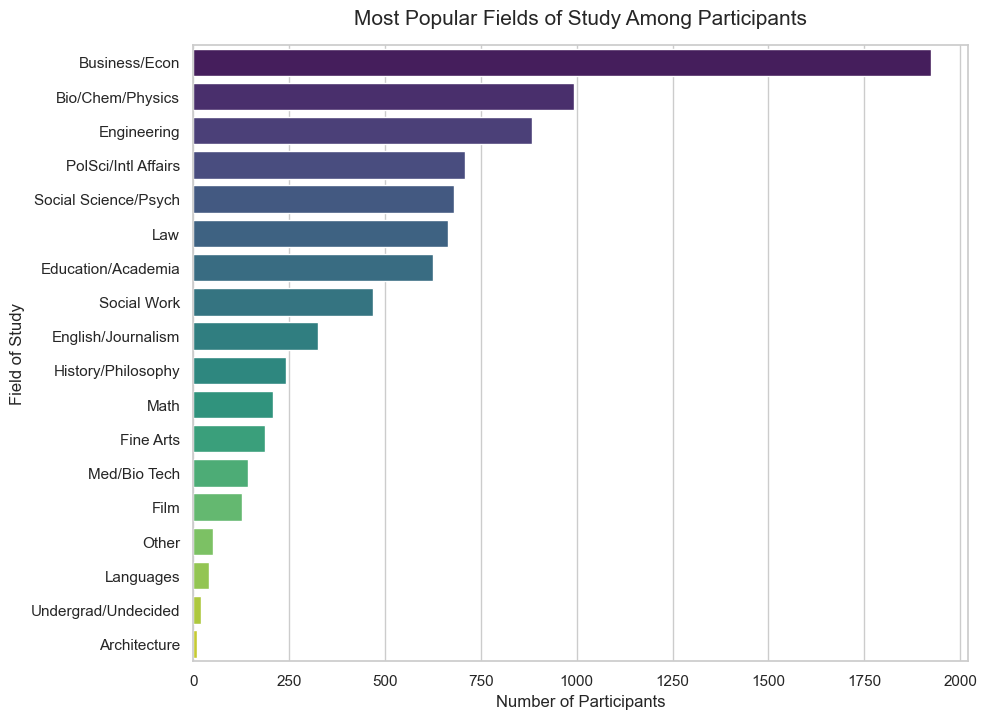

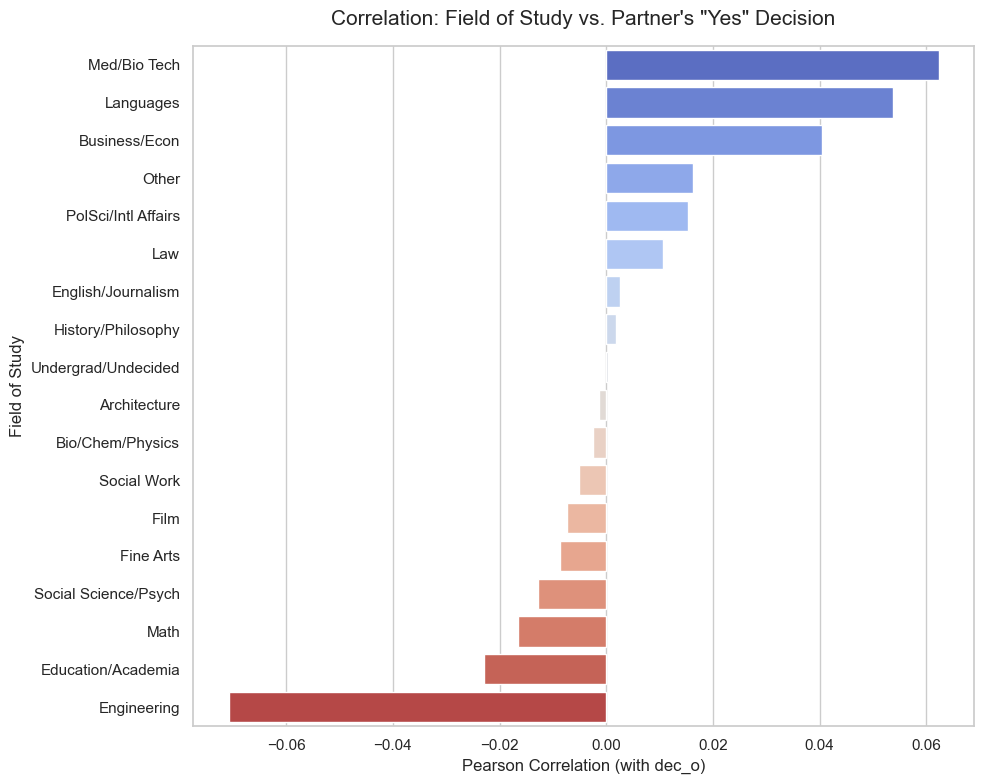

In [259]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

field_mapping = {
    1: 'Law',
    2: 'Math',
    3: 'Social Science/Psych',
    4: 'Med/Bio Tech',
    5: 'Engineering',
    6: 'English/Journalism',
    7: 'History/Philosophy',
    8: 'Business/Econ',
    9: 'Education/Academia',
    10: 'Bio/Chem/Physics',
    11: 'Social Work',
    12: 'Undergrad/Undecided',
    13: 'PolSci/Intl Affairs',
    14: 'Film',
    15: 'Fine Arts',
    16: 'Languages',
    17: 'Architecture',
    18: 'Other'
}

df['field_name'] = df['field_cd'].map(field_mapping)
popular_fields = df['field_name'].value_counts()

plt.figure(figsize=(10, 8))
sns.barplot(
    x=popular_fields.values, 
    y=popular_fields.index, 
    palette='viridis', 
    hue=popular_fields.index, 
    legend=False
)

plt.title('Most Popular Fields of Study Among Participants', fontsize=15, pad=15)
plt.xlabel('Number of Participants', fontsize=12)
plt.ylabel('Field of Study')
plt.show()

field_dummies = pd.get_dummies(df['field_name'], dtype=float)
data_for_field_corr = pd.concat([field_dummies, df['dec_o']], axis=1).dropna()

field_corr = data_for_field_corr.corr()['dec_o'].drop('dec_o').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=field_corr.values, 
    y=field_corr.index, 
    palette='coolwarm', 
    hue=field_corr.index, 
    legend=False
)

plt.title('Correlation: Field of Study vs. Partner\'s "Yes" Decision', fontsize=15, pad=15)
plt.xlabel('Pearson Correlation (with dec_o)', fontsize=12)
plt.ylabel('Field of Study')

plt.tight_layout()
plt.show()

## 10. Gender Differences in Interests
In this section, we compare the hobby ratings of men and women. We want to see if there are any clear patterns in what each gender likes. This helps us understand the different profiles of participants in our dataset.

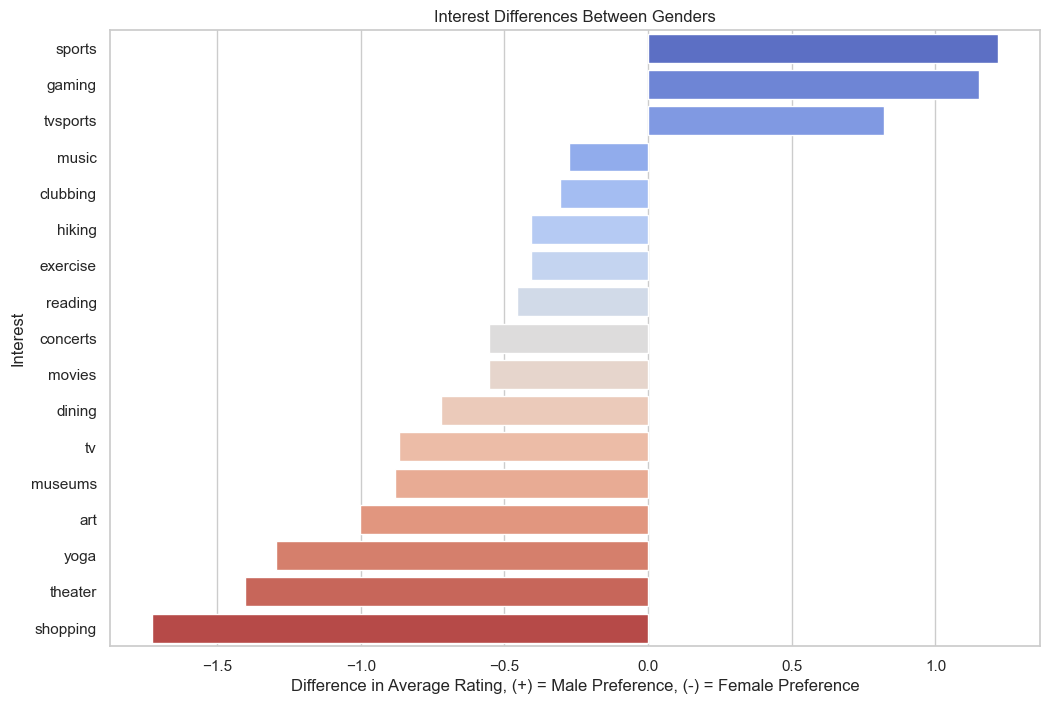

In [260]:
interests = ['sports', 'tvsports', 'exercise', 'dining', 'museums', 
             'art', 'hiking', 'gaming', 'clubbing', 'reading', 
             'tv', 'theater', 'movies', 'concerts', 'music', 
             'shopping', 'yoga']

# Calculate the average score for each hobby grouped by gender (0 = Female, 1 = Male)
gender_interests = df.groupby('gender')[interests].mean().T
gender_interests.columns = ['Female', 'Male']

# Positive values indicate a male preference, negative values indicate a female preference
gender_interests['Difference (Male - Female)'] = gender_interests['Male'] - gender_interests['Female']
gender_interests_sorted = gender_interests.sort_values(by='Difference (Male - Female)', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
x='Difference (Male - Female)',
    y=gender_interests_sorted.index, 
    data=gender_interests_sorted, 
    palette='coolwarm',
    hue=gender_interests_sorted.index,
    legend=False
)


plt.title('Interest Differences Between Genders')
plt.xlabel('Difference in Average Rating, (+) = Male Preference, (-) = Female Preference')
plt.ylabel('Interest')
plt.show()

## 11. Self-Perception vs. Partner Reality
This section compares how participants rate their own attributes against the actual decisions made by their partners to see if self-confidence aligns with external appeal. By splitting the results by gender, we can identify whether certain self-perceived traits—like intelligence or attractiveness—actually correlate with receiving more "Yes" votes in the dating field.

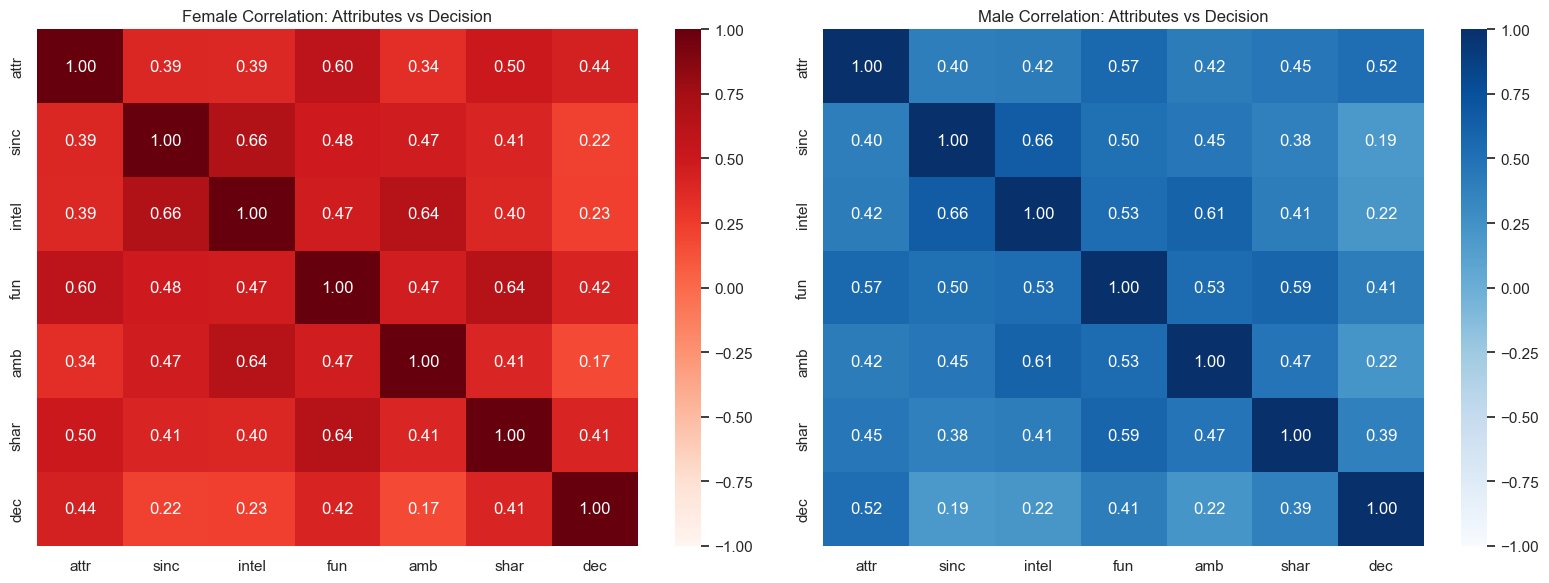

In [261]:
cols_to_corr = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'dec']

female_data = df[df['gender'] == 0][cols_to_corr]
male_data = df[df['gender'] == 1][cols_to_corr]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(female_data.corr(), annot=True, cmap='Reds', fmt=".2f", vmin=-1, vmax=1, ax=ax1)
ax1.set_title('Female Correlation: Attributes vs Decision')

sns.heatmap(male_data.corr(), annot=True, cmap='Blues', fmt=".2f", vmin=-1, vmax=1, ax=ax2)
ax2.set_title('Male Correlation: Attributes vs Decision')

plt.tight_layout()
plt.show()

## 12. Self-Perception vs. Partner Reality
This section compares how participants rate their own attributes against the actual decisions made by their partners to see if self-confidence aligns with external appeal. By splitting the results by gender, we can identify whether certain self-perceived traits—like intelligence or attractiveness—actually correlate with receiving more "Yes" votes in the dating field.

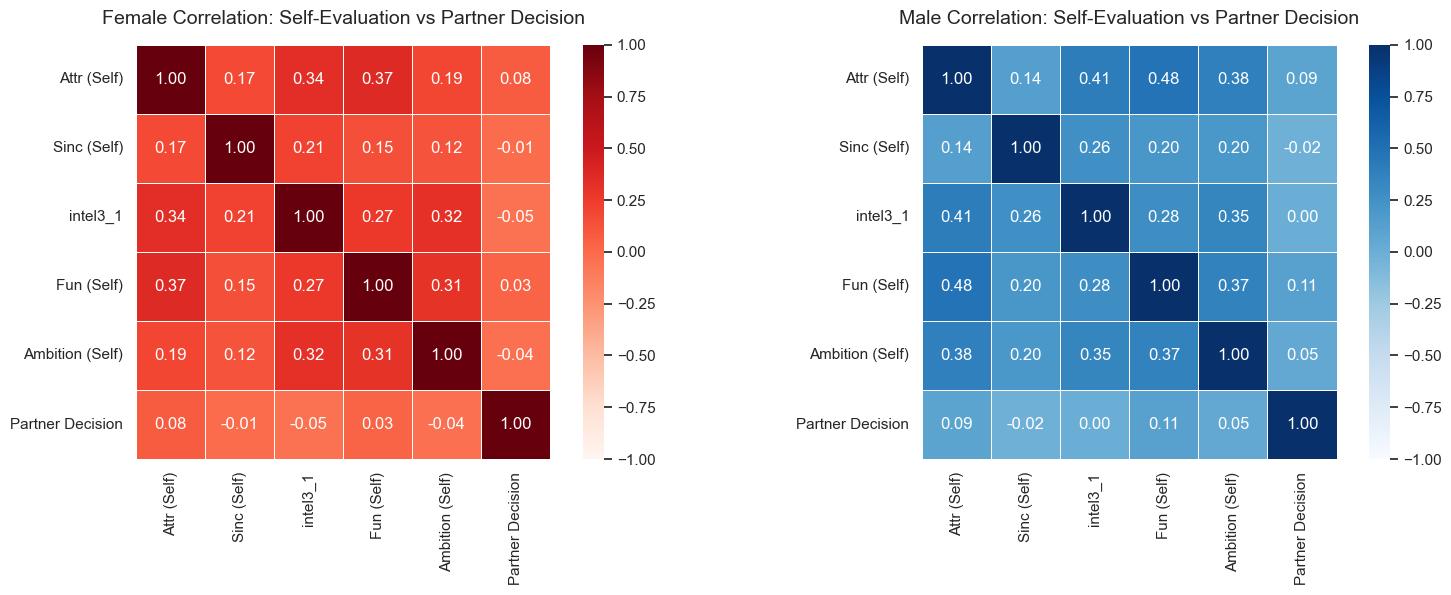

In [262]:
self_eval_cols = ['attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1', 'dec_o']

female_data = df[df['gender'] == 0][self_eval_cols].dropna()
male_data = df[df['gender'] == 1][self_eval_cols].dropna()

rename_dict = {
    'attr3_1': 'Attr (Self)',
    'sinc3_1': 'Sinc (Self)',
    'int3_1': 'Intel (Self)',
    'fun3_1': 'Fun (Self)',
    'amb3_1': 'Ambition (Self)',
    'dec_o': 'Partner Decision'
}
female_data = female_data.rename(columns=rename_dict)
male_data = male_data.rename(columns=rename_dict)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(female_data.corr(), annot=True, cmap='Reds', fmt=".2f", 
            vmin=-1, vmax=1, square=True, ax=ax1, linewidths=.5)
ax1.set_title('Female Correlation: Self-Evaluation vs Partner Decision', fontsize=14, pad=15)

sns.heatmap(male_data.corr(), annot=True, cmap='Blues', fmt=".2f", 
            vmin=-1, vmax=1, square=True, ax=ax2, linewidths=.5)
ax2.set_title('Male Correlation: Self-Evaluation vs Partner Decision', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

## 13. Stated vs. Revealed Preferences
This step compares expectations against reality. We compare what participants claimed was important to them before the event with what they actually cared about during the dates. This analysis helps us spot key behavioral gaps in how people act versus what they say.

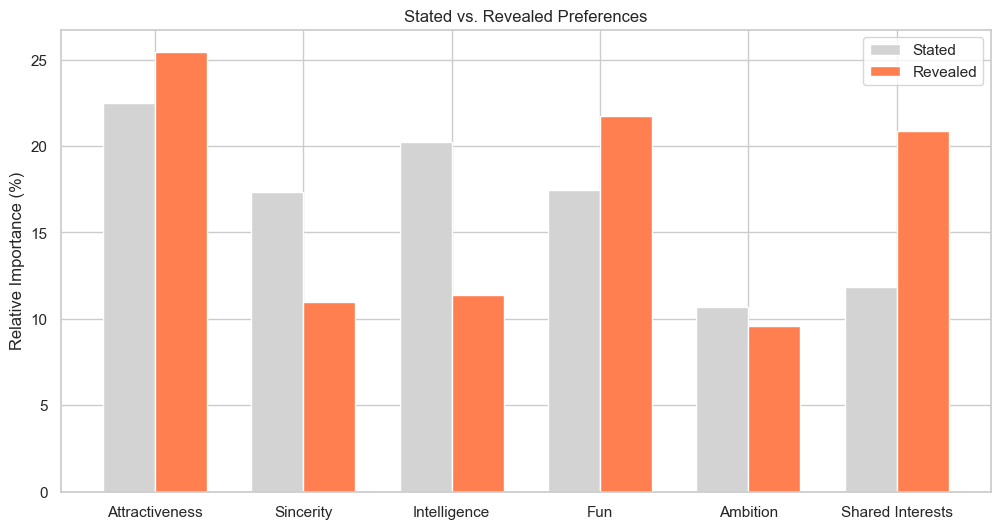

In [263]:
import numpy as np

stated_cols = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
stated_means = df[stated_cols].mean()

stated_normalized = (stated_means / stated_means.sum()) * 100

revealed_corr = df[['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'dec']].corr()['dec'].drop('dec')

revealed_normalized = (revealed_corr / revealed_corr.sum()) * 100

labels = ['Attractiveness', 'Sincerity', 'Intelligence', 'Fun', 'Ambition', 'Shared Interests']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, stated_normalized.values, width, label='Stated', color='lightgray')
ax.bar(x + width/2, revealed_normalized.values, width, label='Revealed', color='coral')

ax.set_ylabel('Relative Importance (%)')
ax.set_title('Stated vs. Revealed Preferences')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()